In [ ]:

Understand DATA -> EDA -> Missing Values -> Outliers -> Anomaly Detection -> Feature Selection -> Categorical Encoding -> Train/Test Split -> Scaling -> Logistic Regression -> Prediction -> Classification Report -> Confusion Matrix -> ROC -> ROC-AUC -> Model Interpretation

In [2]:
#Data Manipulation
import pandas as pd
import numpy as np


#Visualisation
import matplotlib.pyplot as plt

In [3]:
#Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression


#Evaluation
from sklearn.metrics import(
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    roc_curve,
    roc_auc_score
)

In [4]:
#Outlier Detection
from sklearn.ensemble import IsolationForest

#Ignore unnecssary warnings
import warnings
warnings.filterwarnings("ignore")

In [5]:
df = pd.read_csv("/content/titanic.csv") #csv path

In [6]:
#Display 1st five rows
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [7]:
#Understand the Dataset
print("Dataset Shape:", df.shape)

print("\nColumn names:")
print(df.columns)

print("\nDataset Information:")
df.info()

Dataset Shape: (891, 12)

Column names:
Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [8]:
#Descriptive Statistics
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [9]:
#Check Missing Values
missing_values = df.isnull().sum()

print("Missing Values:")
print(missing_values[missing_values > 0])

Missing Values:
Age         177
Cabin       687
Embarked      2
dtype: int64


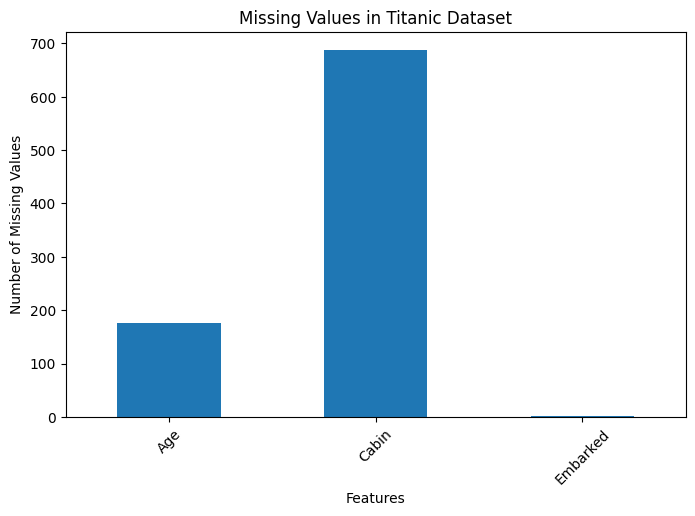

In [10]:
#Visualise Missing Values
missing_values = df.isnull().sum()

missing_values = missing_values[missing_values > 0]

missing_values.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Missing Values in Titanic Dataset")
plt.xlabel("Features")
plt.ylabel("Number of Missing Values")
plt.xticks(rotation=45)
plt.show()

In [12]:
#Handle Missing Values
#For Simplicity

#replace missing Age values with median
#replace missing Embarked values with mode
#remove Cabin because it contains many missing values

#Fill missing Age values using median
df["Age"] = df["Age"].fillna(df["Age"].median())

#Fill missing Embarked values using mode
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

#Remove Cabin
df = df.drop(columns=["Cabin"])

print(df.isnull().sum())

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


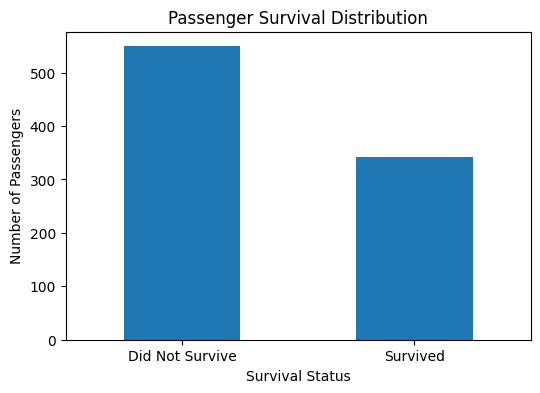

In [15]:
#Exploratory Data Analysis
#Class Distribution
survival_counts = df["Survived"].value_counts()

survival_counts.plot(
    kind="bar",
    figsize=(6,4)
)

plt.title("Passenger Survival Distribution")
plt.xlabel("Survival Status")
plt.ylabel("Number of Passengers")
plt.xticks([0,1], ["Did Not Survive", "Survived"], rotation=0)
plt.show()


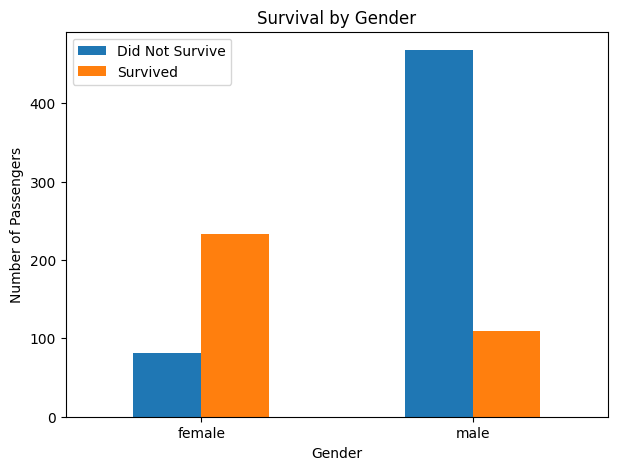

In [17]:
#Survival by Gender
gender_survival =pd.crosstab(
    df["Sex"],
    df["Survived"]
)

gender_survival.plot(
    kind="bar",
    figsize=(7,5)
)

plt.title("Survival by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Passengers")
plt.legend(["Did Not Survive", "Survived"])
plt.xticks(rotation=0)
plt.show()

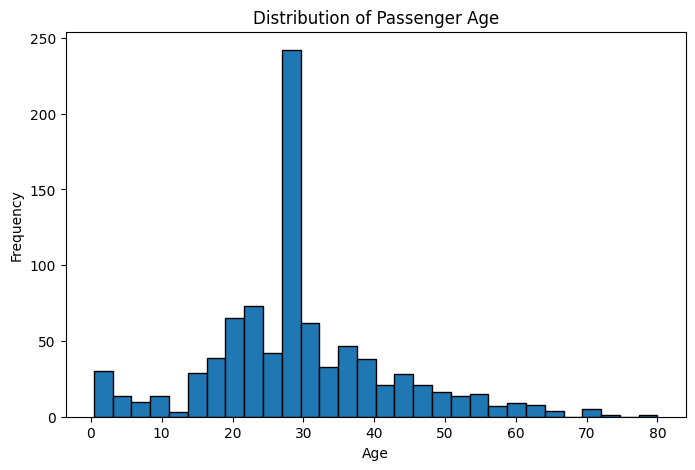

In [19]:
#Age Distribution
plt.figure(figsize=(8,5))

plt.hist(
    df["Age"],
    bins=30,
    edgecolor="black"
)

plt.title("Distribution of Passenger Age")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

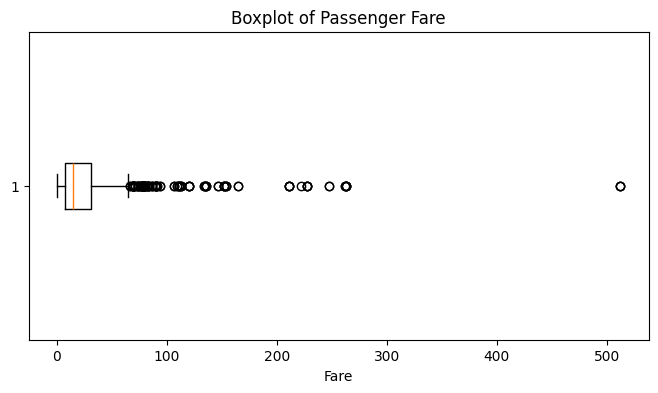

In [20]:
#Detect Outliners Using Boxplot
plt.figure(figsize=(8,4))

plt.boxplot(
    df["Fare"],
    vert=False
)

plt.title("Boxplot of Passenger Fare")
plt.xlabel("Fare")
plt.show()

In [22]:
#Detect Outliers Using IQR
Q1 = df["Fare"].quantile(0.25)
Q3 = df["Fare"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 -  1.5 * IQR
upper_bound = Q3 +  1.5 * IQR

fare_outiers = df[
    (df["Fare"] < lower_bound) | (df["Fare"] > upper_bound)
]

print("Number of Fare outliers:", len(fare_outiers))

fare_outiers[["PassengerId", "Fare"]].head(10)


Number of Fare outliers: 116


,PassengerId,Fare
1,2,71.2833
27,28,263.0000
31,32,146.5208
34,35,82.1708
52,53,76.7292
61,62,80.0000
62,63,83.4750
72,73,73.5000
88,89,263.0000
102,103,77.2875


In [23]:
#Detect Anomalies Using Isolation Forest
anomaly_data = df[["Age", "Fare"]].copy()

isolation_forest =  IsolationForest(
    contamination=0.05,
    random_state=42
)

df["Anomaly"] = isolation_forest.fit_predict(anomaly_data)

print(df["Anomaly"].value_counts())

Anomaly
 1    846
-1     45
Name: count, dtype: int64


In [24]:
anomalies = df[df["Anomaly"] == 1]

anomalies[
    ["PassengerId", "Age", "Fare", "Survived"]
          ].head(10)

,PassengerId,Age,Fare,Survived
0,1,22.0,7.2500,0
1,2,38.0,71.2833,1
2,3,26.0,7.9250,1
3,4,35.0,53.1000,1
4,5,35.0,8.0500,0
5,6,28.0,8.4583,0
6,7,54.0,51.8625,0
7,8,2.0,21.0750,0
8,9,27.0,11.1333,1
9,10,14.0,30.0708,1


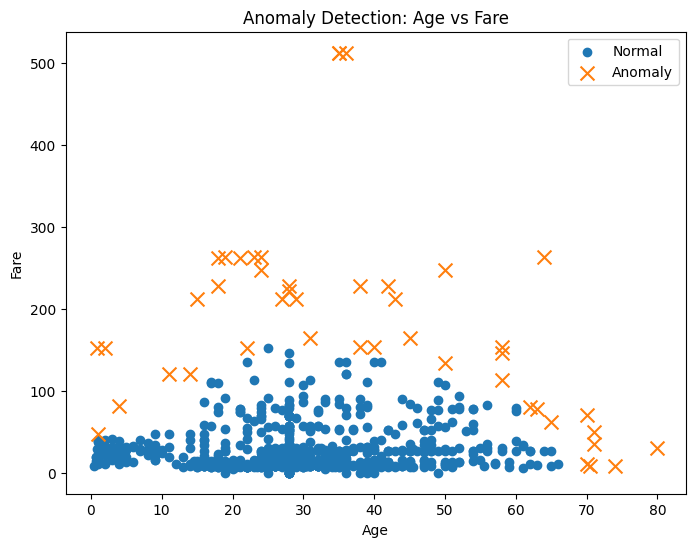

In [26]:
#Visualise the Anomalies
#Outliers and anomalies are related but not necessarily identical concepts
normal = df[df["Anomaly"] == 1]
anomalies = df[df["Anomaly"] == -1]

plt.figure(figsize=(8,6))

plt.scatter(
    normal["Age"],
    normal["Fare"],
    label="Normal"
)

plt.scatter(
    anomalies["Age"],
    anomalies["Fare"],
    marker="x",
    s=100,
    label="Anomaly"
)

plt.xlabel("Age")
plt.ylabel("Fare")
plt.title("Anomaly Detection: Age vs Fare")
plt.legend()
plt.show()

In [30]:
#Select Features for Logistic Regression
features = [
    "Pclass",
    "Sex",
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "Embarked"
] #These features we use them to determince the predictions

X = df[features]
Y = df["Survived"]

X.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,male,22.0,1,0,7.2500,S
1,1,female,38.0,1,0,71.2833,C
2,3,female,26.0,0,0,7.9250,S
3,1,female,35.0,1,0,53.1000,S
4,3,male,35.0,0,0,8.0500,S


In [31]:
#Convert Categorical Variables
X = pd.get_dummies(
    X,
    columns=["Sex", "Embarked"],
    drop_first=True
)

X.head() #Note on previous colab a different method was used to convert

,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,3,22.0,1,0,7.2500,True,False,True
1,1,38.0,1,0,71.2833,False,False,False
2,3,26.0,0,0,7.9250,False,False,True
3,1,35.0,1,0,53.1000,False,False,True
4,3,35.0,0,0,8.0500,True,False,True


In [35]:
#Split the Dataset

#Use 80% for training and 20% for testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Trainig samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Trainig samples: 712
Testing samples: 179


In [36]:
#Feature Scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
#Feeding data into trainig and testing

In [38]:
#Build Logistic Regression Model
model = LogisticRegression(
    max_iter=1000,
    random_state=42

)

model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [39]:
#Make Predictions
y_pred = model.predict(X_test_scaled)

y_probability = model.predict_proba(X_test_scaled)[:,1]

In [40]:
#Calculate Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", round(accuracy, 4))

Accuracy: 0.8045


In [41]:
#Classification Report
print("Classification Report\n")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "Did Not Survive",
            "Survived"
        ]
    )
)

Classification Report

                 precision    recall  f1-score   support

Did Not Survive       0.81      0.89      0.85       110
       Survived       0.79      0.67      0.72        69

       accuracy                           0.80       179
      macro avg       0.80      0.78      0.79       179
   weighted avg       0.80      0.80      0.80       179



In [ ]:
#The report contains four particularly important measures:

#Precision: How many passengers predicted as belong to a class were correctly classified.
#Recall: How many actual members of tha class were correctly deted
#F1-score: Harmonic balance between precion and recall
#Support: Number of observations belonging to each class.

In [42]:
#Confusion Matrix
cm = confusion_matrix(
    y_test,
    y_pred
)

print(cm)

[[98 12]
 [23 46]]


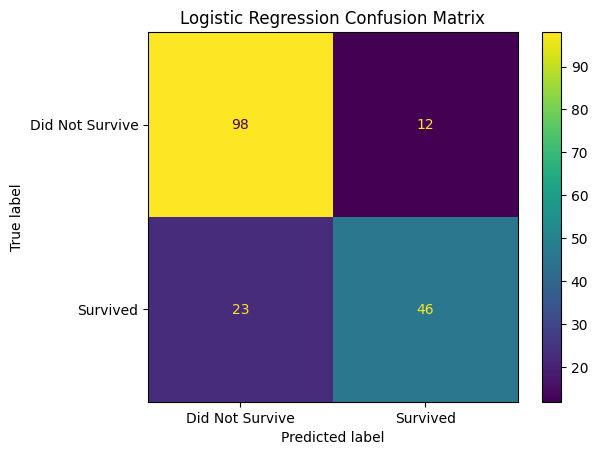

In [43]:
#Visualisen the confusion Matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix = cm,
    display_labels=[
        "Did Not Survive",
        "Survived"
    ]
)

disp.plot()

plt.title("Logistic Regression Confusion Matrix")
plt.show()

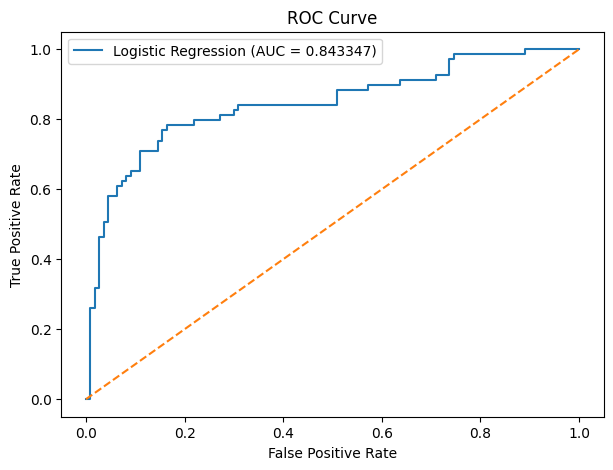

In [44]:
#ROC Curve
fpr, tpr , thresholds = roc_curve(
    y_test,
    y_probability
)

auc = roc_auc_score(
    y_test,
    y_probability
)

plt.figure(figsize=(7,5))

plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC = {auc:3f})"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [46]:
#Examine Logistic Regression Feature Importannce
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

coefficients["Absolute_Coefficient"] = abs(
    coefficients["Coefficient"]
)

coefficients = coefficients.sort_values(
    "Absolute_Coefficient",
    ascending=False
)

coefficients

,Feature,Coefficient,Absolute_Coefficient
5,Sex_male,-1.269598,1.269598
0,Pclass,-0.928698,0.928698
1,Age,-0.502878,0.502878
2,SibSp,-0.262672,0.262672
7,Embarked_S,-0.171784,0.171784
4,Fare,0.099599,0.099599
6,Embarked_Q,0.080683,0.080683
3,Parch,-0.067158,0.067158


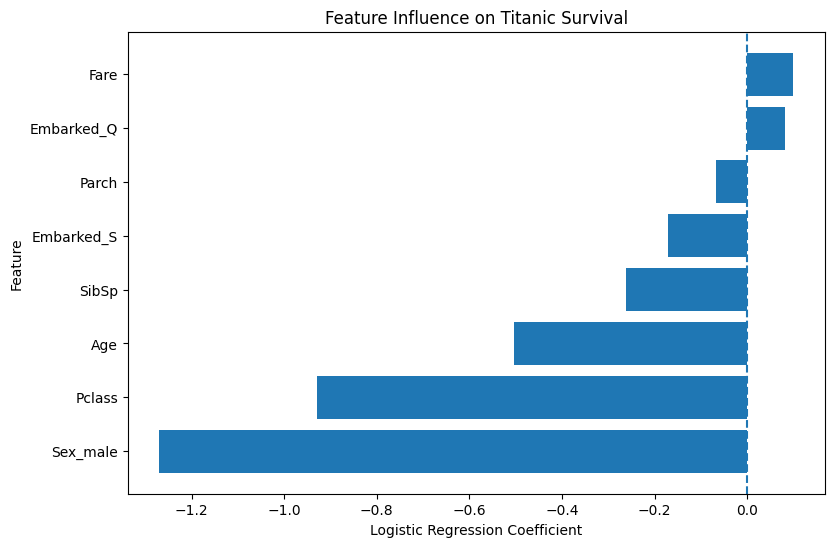

In [47]:
#Visualise Coefficients
coefficients_sorted = coefficients.sort_values(
    "Coefficient"
)

plt.figure(figsize=(9,6))

plt.barh(
    coefficients_sorted["Feature"],
    coefficients_sorted["Coefficient"]
)

plt.axvline(
    0,
    linestyle="--"
)

plt.xlabel("Logistic Regression Coefficient")
plt.ylabel("Feature")
plt.title("Feature Influence on Titanic Survival")

plt.show()